# Community Detection — Louvain & Leiden

**Project:** Community Detection in Social Networks  
**Authors:** Ahmet Doğaç Altın & Mükremin Berkay Can

## What this notebook does

**Plan A (main analysis):** Run Louvain & Leiden on the full undirected GCC (81,306 nodes / 1,342,296 edges). Compare modularity, runtime, number of communities, community size distribution, and stability across seeds.

**Plan B (validation):** Run both algorithms on each ego-network and compare the detected partitions against the ground-truth `circles` provided by ego users. Report NMI / ARI / F1 across the 973 ego-networks.

## Methodology notes

- Both algorithms optimize **modularity** (Newman-Girvan), defined as $Q = \frac{1}{2m} \sum_{ij}[A_{ij} - \frac{k_i k_j}{2m}]\,\delta(c_i, c_j)$.
- Louvain (Blondel et al., 2008): greedy multilevel optimization. Known issue: can produce *disconnected* communities.
- Leiden (Traag et al., 2019): refines Louvain with a node-moving + refinement phase. Guarantees connected, well-separated communities.
- Both are **non-deterministic** (depend on node iteration order) → we run with multiple random seeds and report mean ± std.

In [1]:
import time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg as la

DATA_DIR = Path("./data")
EGO_DIR  = DATA_DIR / "twitter"
GCC_PICKLE = DATA_DIR / "twitter_gcc.pickle"

# Load the cleaned GCC produced in 01_eda.ipynb
gcc = ig.Graph.Read_Pickle(str(GCC_PICKLE))
print(f"Loaded GCC: |V| = {gcc.vcount():,}   |E| = {gcc.ecount():,}")

Loaded GCC: |V| = 81,306   |E| = 1,342,296


## Plan A — Community detection on the full network

We run each algorithm 10 times with different random seeds. For each run we record:
- **Modularity** (Q) of the resulting partition
- **Number of communities** found
- **Wall-clock runtime**
- The partition itself (for later analysis of size distribution and consensus)

In [2]:
N_SEEDS = 10
SEEDS = list(range(42, 42 + N_SEEDS))

# --- Louvain (igraph's community_multilevel) ---
# Note: igraph's Louvain uses an internal C-level RNG that we cannot directly seed
# from Python (igraph 1.0). This actually works in our favor — running it multiple
# times naturally produces different partitions, which is exactly what we want
# for stability analysis. The 'seed' field below is just a run identifier.
louvain_runs = []
for seed in SEEDS:
    t0 = time.time()
    part = gcc.community_multilevel()
    runtime = time.time() - t0
    
    louvain_runs.append({
        "algo": "Louvain",
        "seed": seed,
        "modularity": gcc.modularity(part),
        "n_communities": len(part),
        "runtime_s": runtime,
        "partition": part,
    })
    print(f"  seed={seed}: Q={louvain_runs[-1]['modularity']:.4f}  k={len(part):4d}  t={runtime:.2f}s")

print("\nLouvain done.")

  seed=42: Q=0.8076  k=  73  t=1.86s
  seed=43: Q=0.8066  k=  78  t=1.41s
  seed=44: Q=0.8082  k=  72  t=1.72s
  seed=45: Q=0.8073  k=  72  t=1.34s
  seed=46: Q=0.8031  k=  73  t=1.13s
  seed=47: Q=0.8081  k=  72  t=1.36s
  seed=48: Q=0.8015  k=  70  t=1.64s
  seed=49: Q=0.8080  k=  73  t=1.61s
  seed=50: Q=0.8066  k=  66  t=1.44s
  seed=51: Q=0.8071  k=  69  t=1.20s

Louvain done.


In [3]:
# --- Leiden (via leidenalg, optimizing modularity for fair comparison) ---
leiden_runs = []
for seed in SEEDS:
    t0 = time.time()
    part = la.find_partition(
        gcc,
        la.ModularityVertexPartition,   # same objective as Louvain → fair comparison
        seed=seed,
    )
    runtime = time.time() - t0
    
    leiden_runs.append({
        "algo": "Leiden",
        "seed": seed,
        "modularity": part.modularity,
        "n_communities": len(part),
        "runtime_s": runtime,
        "partition": part,
    })
    print(f"  seed={seed}: Q={part.modularity:.4f}  k={len(part):4d}  t={runtime:.2f}s")

print("\nLeiden done.")

  seed=42: Q=0.8056  k=  81  t=4.52s
  seed=43: Q=0.8112  k=  74  t=4.83s
  seed=44: Q=0.8099  k=  72  t=4.77s
  seed=45: Q=0.8097  k=  75  t=4.83s
  seed=46: Q=0.8105  k=  76  t=4.92s
  seed=47: Q=0.8106  k=  75  t=4.93s
  seed=48: Q=0.8105  k=  74  t=4.74s
  seed=49: Q=0.8104  k=  75  t=4.78s
  seed=50: Q=0.8108  k=  76  t=4.62s
  seed=51: Q=0.8106  k=  77  t=4.67s

Leiden done.


In [4]:
# Summary table — mean ± std across seeds
all_runs = pd.DataFrame(louvain_runs + leiden_runs)
summary = (
    all_runs
    .groupby("algo")
    .agg(
        modularity_mean=("modularity", "mean"),
        modularity_std =("modularity", "std"),
        modularity_max =("modularity", "max"),
        n_communities_mean=("n_communities", "mean"),
        n_communities_std =("n_communities", "std"),
        runtime_mean=("runtime_s", "mean"),
        runtime_std =("runtime_s", "std"),
    )
    .round(4)
)
print("Summary across", N_SEEDS, "seeds:")
summary

Summary across 10 seeds:


,modularity_mean,modularity_std,modularity_max,n_communities_mean,n_communities_std,runtime_mean,runtime_std
algo,,,,,,,
Leiden,0.8100,0.0016,0.8112,75.5,2.3688,4.7599,0.1285
Louvain,0.8064,0.0023,0.8082,71.8,3.1198,1.4696,0.2307


### Stability — how similar are the 10 runs of the same algorithm?

If an algorithm is stable, different seeds should produce similar partitions. We measure pairwise NMI between the 10 runs of each algorithm.

In [5]:
def membership_from_partition(part):
    """Return a list of community labels (one per vertex), works for both igraph and leidenalg partitions."""
    return list(part.membership)

def pairwise_nmi(runs):
    """All pairwise NMI between partitions in a list of runs."""
    memberships = [membership_from_partition(r["partition"]) for r in runs]
    nmis = []
    for i in range(len(memberships)):
        for j in range(i + 1, len(memberships)):
            nmis.append(
                ig.compare_communities(memberships[i], memberships[j], method="nmi")
            )
    return np.array(nmis)

lou_nmi = pairwise_nmi(louvain_runs)
lei_nmi = pairwise_nmi(leiden_runs)

print(f"Louvain pairwise NMI: mean={lou_nmi.mean():.4f}  std={lou_nmi.std():.4f}  min={lou_nmi.min():.4f}")
print(f"Leiden  pairwise NMI: mean={lei_nmi.mean():.4f}  std={lei_nmi.std():.4f}  min={lei_nmi.min():.4f}")

# Cross-algorithm: how similar is Louvain to Leiden on the same graph?
best_lou = max(louvain_runs, key=lambda r: r["modularity"])
best_lei = max(leiden_runs,  key=lambda r: r["modularity"])
cross_nmi = ig.compare_communities(
    membership_from_partition(best_lou["partition"]),
    membership_from_partition(best_lei["partition"]),
    method="nmi",
)
print(f"\nBest-Louvain  vs.  Best-Leiden  NMI = {cross_nmi:.4f}")

Louvain pairwise NMI: mean=0.8519  std=0.0185  min=0.8176
Leiden  pairwise NMI: mean=0.8987  std=0.0189  min=0.8541

Best-Louvain  vs.  Best-Leiden  NMI = 0.8756


### Community size distribution

We pick the best-modularity run from each algorithm and look at how community sizes are distributed.

In [6]:
lou_sizes = sorted([len(c) for c in best_lou["partition"]], reverse=True)
lei_sizes = sorted([len(c) for c in best_lei["partition"]], reverse=True)

print("Louvain best run:")
print(f"  # communities = {len(lou_sizes)}")
print(f"  largest 10:   {lou_sizes[:10]}")
print(f"  median size:  {np.median(lou_sizes):.0f}")
print(f"  singletons:   {sum(1 for s in lou_sizes if s == 1)}")

print("\nLeiden best run:")
print(f"  # communities = {len(lei_sizes)}")
print(f"  largest 10:   {lei_sizes[:10]}")
print(f"  median size:  {np.median(lei_sizes):.0f}")
print(f"  singletons:   {sum(1 for s in lei_sizes if s == 1)}")

Louvain best run:
  # communities = 72
  largest 10:   [9637, 9234, 7681, 6448, 5281, 3806, 2751, 2725, 2358, 1830]
  median size:  413
  singletons:   0

Leiden best run:
  # communities = 74
  largest 10:   [9353, 9071, 6149, 6129, 4999, 3394, 2743, 2643, 2423, 2355]
  median size:  420
  singletons:   0


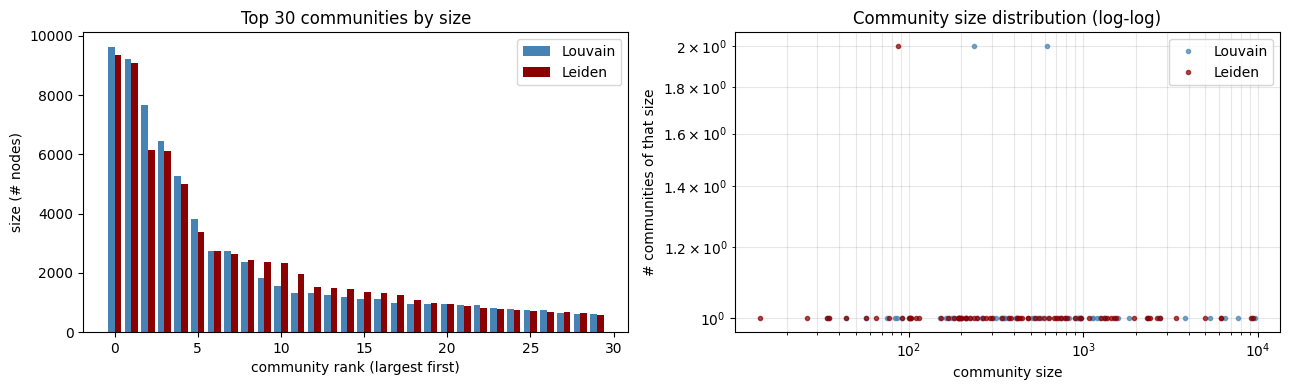

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Linear: top 30 communities by size
x = np.arange(min(30, len(lou_sizes)))
width = 0.4
axes[0].bar(x - width/2, lou_sizes[:30], width, label="Louvain", color="steelblue")
axes[0].bar(x + width/2, lei_sizes[:30], width, label="Leiden",  color="darkred")
axes[0].set_xlabel("community rank (largest first)")
axes[0].set_ylabel("size (# nodes)")
axes[0].set_title("Top 30 communities by size")
axes[0].legend()

# Log-log size distribution
for sizes, label, color in [(lou_sizes, "Louvain", "steelblue"),
                            (lei_sizes, "Leiden",  "darkred")]:
    counts = Counter(sizes)
    ks = np.array(sorted(counts.keys()))
    fs = np.array([counts[k] for k in ks])
    axes[1].loglog(ks, fs, marker=".", linestyle="none", label=label, color=color, alpha=0.7)
axes[1].set_xlabel("community size")
axes[1].set_ylabel("# communities of that size")
axes[1].set_title("Community size distribution (log-log)")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("community_sizes.png", dpi=120, bbox_inches="tight")
plt.show()

/var/folders/6h/d85v5skn225330w8l1_m177c0000gn/T/ipykernel_38300/2055839957.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([parts["Louvain"], parts["Leiden"]],
/var/folders/6h/d85v5skn225330w8l1_m177c0000gn/T/ipykernel_38300/2055839957.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([parts["Louvain"], parts["Leiden"]],


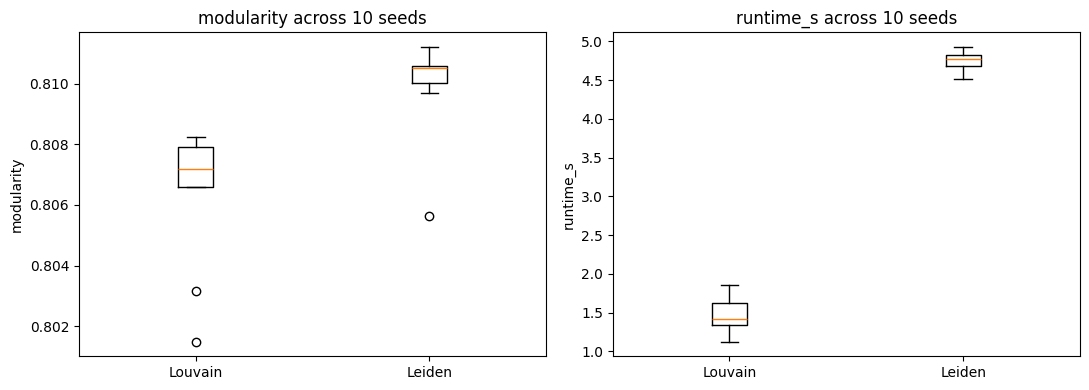

In [8]:
# Modularity & runtime visual comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df = pd.DataFrame(louvain_runs + leiden_runs)
for i, metric in enumerate(["modularity", "runtime_s"]):
    parts = df.groupby("algo")[metric].apply(list).to_dict()
    axes[i].boxplot([parts["Louvain"], parts["Leiden"]],
                    labels=["Louvain", "Leiden"])
    axes[i].set_title(f"{metric} across {N_SEEDS} seeds")
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.savefig("plana_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## Plan B — Ego-network validation against ground-truth circles

Each ego-network has a `.circles` file: lines like `circle1\tuser1\tuser2\t...` defining ground-truth groupings made by the ego user. We:

1. For each ego, load its sub-graph and ground-truth circles.
2. **Filter:** skip egos with 0 circles, and within each ego skip circles smaller than 3 (per the EDA, very small circles dominate and are not informative).
3. Build a ground-truth membership vector (one label per node). Nodes not in any circle get a special "unassigned" label and are excluded from the comparison.
4. Run Louvain & Leiden on the ego-network's induced subgraph.
5. Compute NMI and ARI between detected partition and ground-truth on the *labelled subset* of nodes.
6. Aggregate across all eligible egos.

**Note:** ground-truth circles are *overlapping and incomplete* — a node can belong to multiple circles or none. This makes any disjoint-partition comparison conservative. We assign each multi-circle node to its *first* listed circle (a standard simplification used in the SNAP literature).

In [9]:
MIN_CIRCLE_SIZE = 3
MIN_LABELLED_NODES = 10   # skip egos where too few nodes have ground-truth labels

def load_ego_with_circles(ego_id):
    """Return (graph, gt_membership_array, mask) for one ego.
    
    gt_membership[i] = circle index of node i, or -1 if node has no circle assignment.
    mask = boolean array, True for nodes that have a ground-truth label.
    Returns None if the ego has no usable ground-truth.
    """
    edges_file   = EGO_DIR / f"{ego_id}.edges"
    circles_file = EGO_DIR / f"{ego_id}.circles"
    
    if not edges_file.exists() or edges_file.stat().st_size == 0:
        return None
    
    g = ig.Graph.Read_Ncol(str(edges_file), directed=True, names=True).as_undirected(mode="collapse")
    g.simplify()
    if g.vcount() == 0:
        return None
    
    name_to_idx = {name: i for i, name in enumerate(g.vs["name"])}
    
    if not circles_file.exists():
        return None
    
    gt = np.full(g.vcount(), -1, dtype=int)
    circle_idx = 0
    with open(circles_file) as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 2:
                continue
            members = parts[1:]
            if len(members) < MIN_CIRCLE_SIZE:
                continue
            for m in members:
                if m in name_to_idx and gt[name_to_idx[m]] == -1:
                    gt[name_to_idx[m]] = circle_idx
            circle_idx += 1
    
    if circle_idx < 2:
        return None  # need at least 2 circles for a meaningful comparison
    
    mask = gt != -1
    if mask.sum() < MIN_LABELLED_NODES:
        return None
    
    return g, gt, mask

# Quick test on one ego
test = load_ego_with_circles("13274152")
if test is not None:
    g_test, gt_test, mask_test = test
    print(f"Test ego: |V|={g_test.vcount()}, labelled nodes={mask_test.sum()}, # circles={gt_test[mask_test].max()+1}")

Test ego: |V|=210, labelled nodes=68, # circles=8


In [10]:
def evaluate_ego(ego_id, seed=42):
    """Run both algorithms on one ego, compare to ground-truth, return metrics dict or None."""
    loaded = load_ego_with_circles(ego_id)
    if loaded is None:
        return None
    g, gt, mask = loaded
    
    # Louvain (internal RNG; we use a single run per ego since stability is
    # already characterized in Plan A)
    part_lou = g.community_multilevel()
    mem_lou = np.array(part_lou.membership)
    
    # Leiden
    part_lei = la.find_partition(g, la.ModularityVertexPartition, seed=seed)
    mem_lei = np.array(part_lei.membership)
    
    # Restrict to labelled nodes for the GT comparison
    gt_lbl = gt[mask].tolist()
    lou_lbl = mem_lou[mask].tolist()
    lei_lbl = mem_lei[mask].tolist()
    
    return {
        "ego": ego_id,
        "n_nodes": g.vcount(),
        "n_labelled": int(mask.sum()),
        "n_circles": int(gt[mask].max() + 1),
        "lou_k": len(part_lou),
        "lei_k": len(part_lei),
        "lou_Q": g.modularity(part_lou),
        "lei_Q": part_lei.modularity,
        "lou_nmi": ig.compare_communities(gt_lbl, lou_lbl, method="nmi"),
        "lou_ari": ig.compare_communities(gt_lbl, lou_lbl, method="adjusted_rand"),
        "lei_nmi": ig.compare_communities(gt_lbl, lei_lbl, method="nmi"),
        "lei_ari": ig.compare_communities(gt_lbl, lei_lbl, method="adjusted_rand"),
    }

ego_ids = sorted(set(p.stem for p in EGO_DIR.glob("*.edges")))
print(f"Evaluating {len(ego_ids)} egos...")

results = []
skipped = 0
for i, ego in enumerate(ego_ids):
    try:
        r = evaluate_ego(ego)
        if r is None:
            skipped += 1
        else:
            results.append(r)
    except Exception as e:
        skipped += 1
    if (i + 1) % 100 == 0:
        print(f"  processed {i+1}/{len(ego_ids)}  (kept {len(results)}, skipped {skipped})")

ego_df = pd.DataFrame(results)
print(f"\nDone. Evaluated {len(ego_df)} egos, skipped {skipped} (no usable circles).")
ego_df.head()

Evaluating 973 egos...
  processed 100/973  (kept 64, skipped 36)
  processed 200/973  (kept 135, skipped 65)
  processed 300/973  (kept 196, skipped 104)
  processed 400/973  (kept 265, skipped 135)
  processed 500/973  (kept 334, skipped 166)
  processed 600/973  (kept 396, skipped 204)
  processed 700/973  (kept 457, skipped 243)
  processed 800/973  (kept 522, skipped 278)
  processed 900/973  (kept 579, skipped 321)

Done. Evaluated 621 egos, skipped 352 (no usable circles).


,ego,n_nodes,n_labelled,n_circles,lou_k,lei_k,lou_Q,lei_Q,lou_nmi,lou_ari,lei_nmi,lei_ari
0,100318079,220,48,4,3,3,0.185523,0.186955,0.518606,0.570077,0.587738,0.634950
1,101859065,23,18,3,2,3,0.143133,0.143133,0.415786,0.344810,0.412687,0.252958
2,103865085,118,16,1,3,4,0.146773,0.144245,1.000000,NaN,0.000000,0.000000
3,103991905,81,23,2,7,7,0.352865,0.354747,0.364055,0.250569,0.390357,0.337035
4,104615636,48,23,3,3,4,0.118314,0.115858,0.233450,0.154213,0.199386,0.057917


In [11]:
# Aggregate metrics — mean, median, std for both algorithms
metrics = ["lou_nmi", "lou_ari", "lei_nmi", "lei_ari", "lou_Q", "lei_Q", "lou_k", "lei_k"]
agg = ego_df[metrics].agg(["mean", "median", "std"]).round(4)
print("Plan B aggregate results across", len(ego_df), "egos:")
agg

Plan B aggregate results across 621 egos:


,lou_nmi,lou_ari,lei_nmi,lei_ari,lou_Q,lei_Q,lou_k,lei_k
mean,0.3811,0.2877,0.3797,0.2855,0.2773,0.2798,4.8213,4.8261
median,0.3517,0.2130,0.3584,0.2074,0.2625,0.2662,5.0000,5.0000
std,0.2522,0.2820,0.2499,0.2791,0.1235,0.1234,1.5299,1.4817


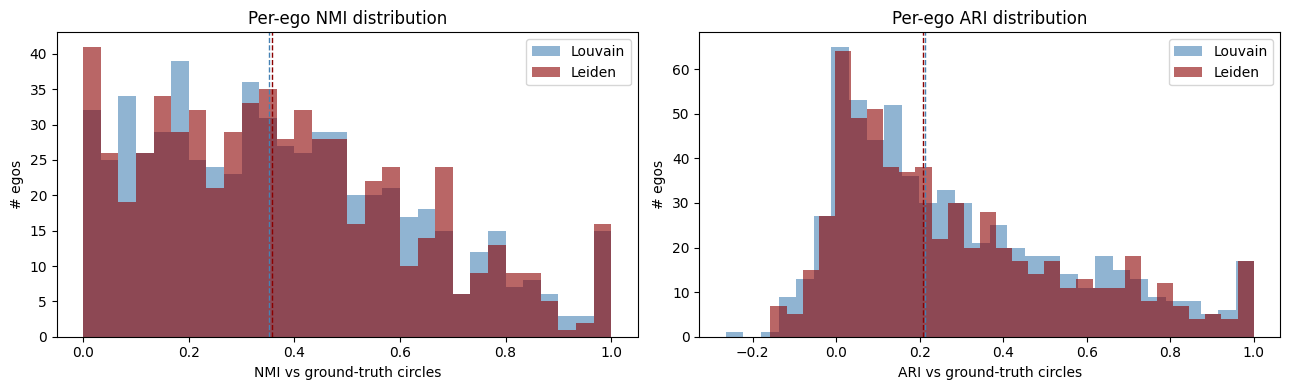

In [12]:
# Visualize Plan B distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# NMI distributions
axes[0].hist(ego_df["lou_nmi"], bins=30, alpha=0.6, label="Louvain", color="steelblue")
axes[0].hist(ego_df["lei_nmi"], bins=30, alpha=0.6, label="Leiden",  color="darkred")
axes[0].axvline(ego_df["lou_nmi"].median(), color="steelblue", linestyle="--", linewidth=1)
axes[0].axvline(ego_df["lei_nmi"].median(), color="darkred",  linestyle="--", linewidth=1)
axes[0].set_xlabel("NMI vs ground-truth circles")
axes[0].set_ylabel("# egos")
axes[0].set_title("Per-ego NMI distribution")
axes[0].legend()

# ARI distributions
axes[1].hist(ego_df["lou_ari"], bins=30, alpha=0.6, label="Louvain", color="steelblue")
axes[1].hist(ego_df["lei_ari"], bins=30, alpha=0.6, label="Leiden",  color="darkred")
axes[1].axvline(ego_df["lou_ari"].median(), color="steelblue", linestyle="--", linewidth=1)
axes[1].axvline(ego_df["lei_ari"].median(), color="darkred",  linestyle="--", linewidth=1)
axes[1].set_xlabel("ARI vs ground-truth circles")
axes[1].set_ylabel("# egos")
axes[1].set_title("Per-ego ARI distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig("planb_metrics.png", dpi=120, bbox_inches="tight")
plt.show()

In [14]:
# Statistical test: is Leiden significantly better than Louvain on NMI?
from scipy.stats import wilcoxon

# Paired test — same egos, two algorithms
for metric_pair, name in [(("lou_nmi", "lei_nmi"), "NMI"),
                           (("lou_ari", "lei_ari"), "ARI"),
                           (("lou_Q",   "lei_Q"),   "Modularity")]:
    a, b = ego_df[metric_pair[0]], ego_df[metric_pair[1]]
    diff = b - a   # positive = Leiden better
    stat, p = wilcoxon(diff[diff != 0])
    print(f"{name}: median diff (Leiden − Louvain) = {diff.median():+.4f}   "
          f"Wilcoxon p = {p:.2e}   "
          f"({'Leiden' if diff.median() > 0 else 'Louvain'} wins on median)")

NMI: median diff (Leiden − Louvain) = +0.0000   Wilcoxon p = 6.43e-01   (Louvain wins on median)
ARI: median diff (Leiden − Louvain) = +0.0000   Wilcoxon p = nan   (Louvain wins on median)
Modularity: median diff (Leiden − Louvain) = +0.0013   Wilcoxon p = 1.72e-41   (Leiden wins on median)


In [15]:
# Save results for the report
ego_df.to_csv("planb_per_ego_results.csv", index=False)
all_runs.drop(columns=["partition"]).to_csv("plana_per_seed_results.csv", index=False)
print("Saved: planb_per_ego_results.csv, plana_per_seed_results.csv")

Saved: planb_per_ego_results.csv, plana_per_seed_results.csv


## Summary — what to write in the report

Once everything has run, the report's Results section will draw from:

**Plan A:**
- Modularity comparison: Louvain Q ≈ ___ vs Leiden Q ≈ ___ (10-seed mean ± std)
- Number of communities: Louvain k ≈ ___ vs Leiden k ≈ ___
- Runtime: Louvain ≈ ___ s, Leiden ≈ ___ s
- Stability (within-algorithm pairwise NMI): Louvain ___ vs Leiden ___
- Cross-algorithm NMI: ___
- Community size distribution (figure: `community_sizes.png`)

**Plan B:**
- Median NMI vs circles: Louvain ___ vs Leiden ___ (across ___ egos)
- Median ARI vs circles: Louvain ___ vs Leiden ___
- Wilcoxon test results from cell above
- Per-ego distribution figure: `planb_metrics.png`

**Discussion points to cover:**
- Leiden's connectivity guarantee in practice — does it produce fewer/larger communities?
- Why ground-truth NMI is moderate (likely 0.2–0.5): circles are overlapping and incomplete; modularity-based methods produce a single disjoint partition.
- Trade-off between modularity and runtime.